IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

SET PATH

In [3]:
BASE_DIR = Path("..")

RAW_DATA_PATH = BASE_DIR / "data" / "raw" / "Online Retail.xlsx"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
FIGURES_DIR = BASE_DIR / "outputs" / "figures"
TABLES_DIR = BASE_DIR / "outputs" / "tables"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Project folders ready.")

Project folders ready.


LOAD DATASET

In [4]:
df = pd.read_excel(RAW_DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


BASIC INFORMATION OF DATASET

In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Rows: 541909
Columns: 8

Column Names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data Types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object


MISSING VALUES

In [6]:
missing_values = df.isnull().sum().reset_index()
missing_values.columns = ["Column", "Missing_Values"]
missing_values["Missing_Percentage"] = (missing_values["Missing_Values"] / len(df) * 100).round(2)

missing_values

,Column,Missing_Values,Missing_Percentage
0,InvoiceNo,0,0.00
1,StockCode,0,0.00
2,Description,1454,0.27
3,Quantity,0,0.00
4,InvoiceDate,0,0.00
5,UnitPrice,0,0.00
6,CustomerID,135080,24.93
7,Country,0,0.00


SAVING MISSING VALUE

In [7]:
missing_values.to_csv(TABLES_DIR / "missing_values_summary.csv", index=False)

print("Missing value summary saved.")

Missing value summary saved.


DATASET DATE RANGE

In [8]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("Start Date:", df["InvoiceDate"].min())
print("End Date:", df["InvoiceDate"].max())
print("Total Period:", df["InvoiceDate"].max() - df["InvoiceDate"].min())

Start Date: 2010-12-01 08:26:00
End Date: 2011-12-09 12:50:00
Total Period: 373 days 04:24:00


SUMARRY FOR CUSTOMER,PRODUCT

In [9]:
summary = {
    "Total Transactions": df.shape[0],
    "Unique Customers": df["CustomerID"].nunique(),
    "Unique Countries": df["Country"].nunique(),
    "Unique Products": df["StockCode"].nunique(),
    "Unique Invoices": df["InvoiceNo"].nunique()
}

summary_df = pd.DataFrame(summary.items(), columns=["Metric", "Value"])

summary_df

,Metric,Value
0,Total Transactions,541909
1,Unique Customers,4372
2,Unique Countries,38
3,Unique Products,4070
4,Unique Invoices,25900


DATASET SUMMARY

In [10]:
summary_df.to_csv(TABLES_DIR / "dataset_summary.csv", index=False)

print("Dataset summary saved.")

Dataset summary saved.


CANCELLED INVOICE

In [11]:
cancelled_invoices = df[df["InvoiceNo"].astype(str).str.startswith("C")]

print("Cancelled invoice records:", cancelled_invoices.shape[0])

cancelled_invoices.head()

Cancelled invoice records: 9288


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


NEGATIVE PRICE, QUANTITY

In [12]:
print("Negative quantity records:", (df["Quantity"] < 0).sum())
print("Zero or negative price records:", (df["UnitPrice"] <= 0).sum())

Negative quantity records: 10624
Zero or negative price records: 2517


REVENUE 

In [13]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

df[["Quantity", "UnitPrice", "TotalPrice"]].describe()

,Quantity,UnitPrice,TotalPrice
count,541909.000000,541909.000000,541909.000000
mean,9.552250,4.611114,17.987795
std,218.081158,96.759853,378.810824
min,-80995.000000,-11062.060000,-168469.600000
25%,1.000000,1.250000,3.400000
50%,3.000000,2.080000,9.750000
75%,10.000000,4.130000,17.400000
max,80995.000000,38970.000000,168469.600000


TOP 10 COUNTRIES BY TRANSACTIONS

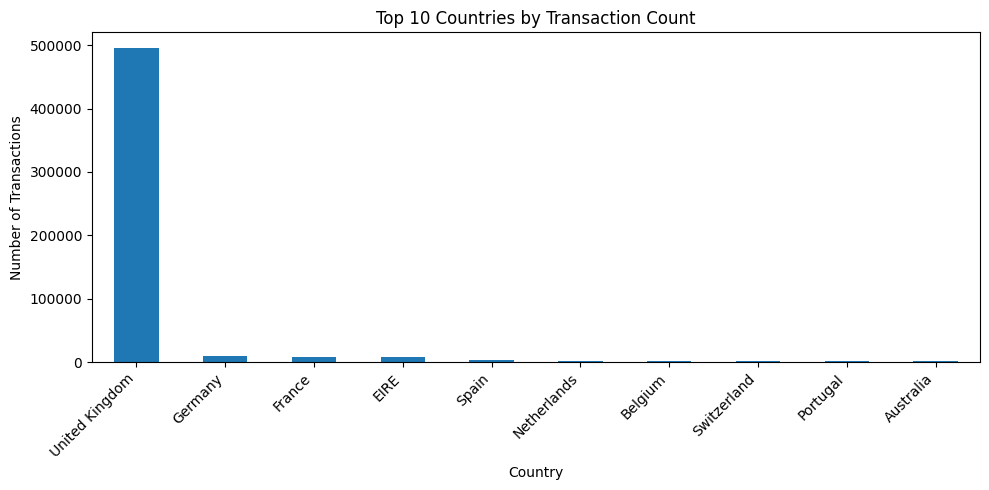

In [14]:
top_countries = df["Country"].value_counts().head(10)

plt.figure(figsize=(10, 5))
top_countries.plot(kind="bar")
plt.title("Top 10 Countries by Transaction Count")
plt.xlabel("Country")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "top_10_countries_transactions.png", dpi=300)
plt.show()

MONTHLY TRANSACTION TREND 

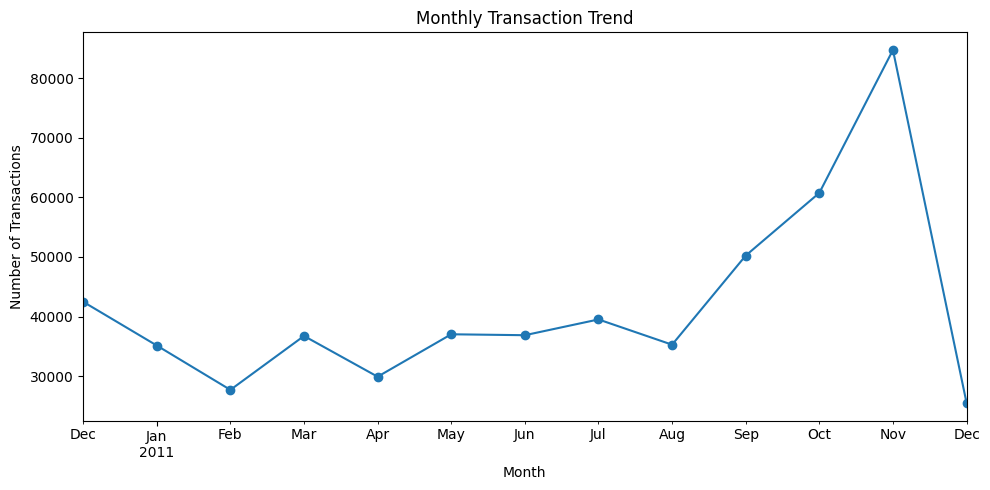

In [15]:
monthly_transactions = df.set_index("InvoiceDate").resample("M")["InvoiceNo"].count()

plt.figure(figsize=(10, 5))
monthly_transactions.plot(marker="o")
plt.title("Monthly Transaction Trend")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "monthly_transaction_trend.png", dpi=300)
plt.show()

MONTHLY REVENUE TREND

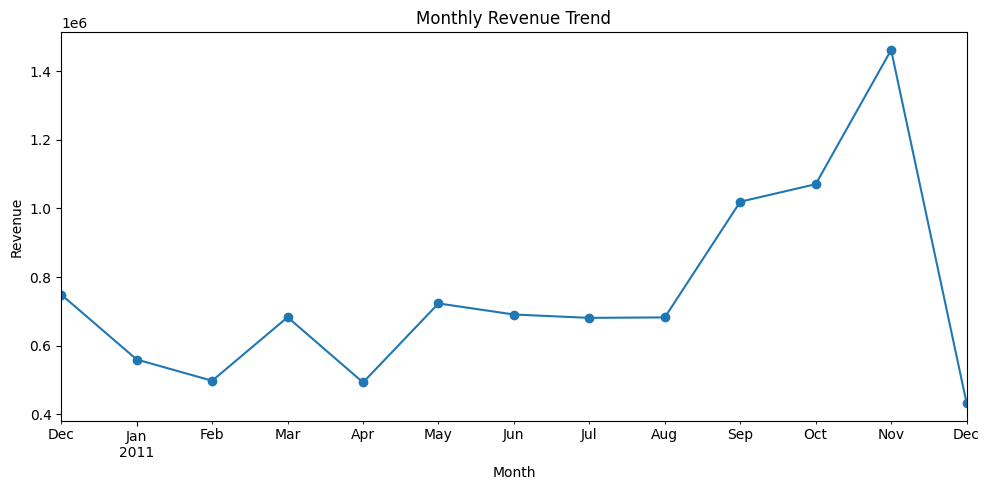

In [16]:
monthly_revenue = df.set_index("InvoiceDate").resample("M")["TotalPrice"].sum()

plt.figure(figsize=(10, 5))
monthly_revenue.plot(marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "monthly_revenue_trend.png", dpi=300)
plt.show()

TOP 10 PRODUCTS BY QUANTITY

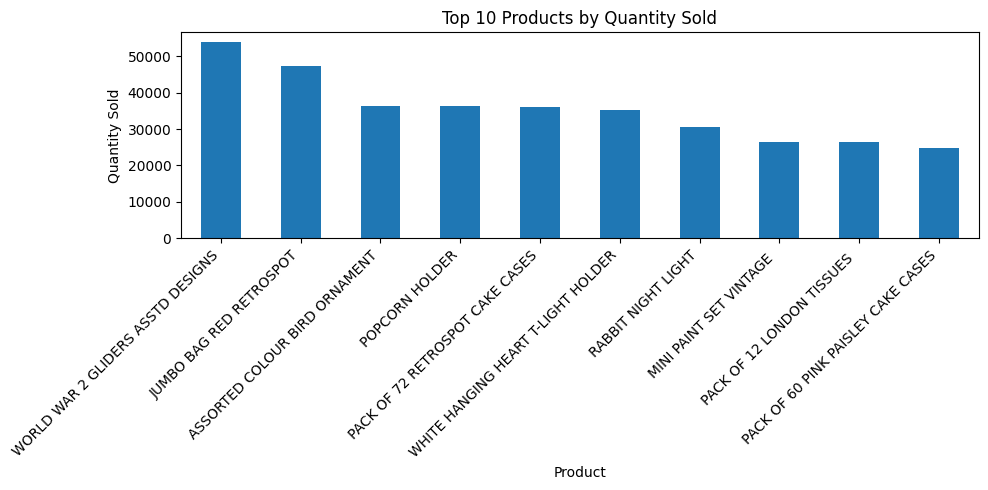

In [17]:
top_products = (
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
top_products.plot(kind="bar")
plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "top_10_products_quantity.png", dpi=300)
plt.show()

FINAL EXPLANATION 

In [ ]:
print("DATA UNDERSTANDING SUMMARY")
print("--------------------------")
print(f"The dataset contains {df.shape[0]:,} transaction records and {df.shape[1]} columns.")
print(f"There are approximately {df['CustomerID'].nunique():,} unique customers across {df['Country'].nunique()} countries.")
print(f"The dataset covers transactions from {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}.")
print("The dataset contains missing CustomerID values, cancelled invoices, negative quantities, and invalid prices, which must be handled in the cleaning stage.")

DATA UNDERSTANDING SUMMARY
--------------------------
The dataset contains 541,909 transaction records and 9 columns.
There are approximately 4,372 unique customers across 38 countries.
The dataset covers transactions from 2010-12-01 to 2011-12-09.
The dataset contains missing CustomerID values, cancelled invoices, negative quantities, and invalid prices, which must be handled in the cleaning stage.


: 